In [44]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm   
import matplotlib.colors as mcolors
from src import import_data as i_d
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

In [45]:
i_d.charger_donnees_depuis_bureau()

Dossier trouvé : /Users/charles.ozeel/Desktop/donnees_formule_un
Fichiers CSV trouvés : [PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/circuits.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/status.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/lap_times.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/sprint_results.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/drivers.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/races.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructors.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructor_standings.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/qualifying.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/driver_standings.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructor_results.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees

In [46]:
pit_stops

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842
...,...,...,...,...,...,...,...
10985,1132,807,2,39,16:06:28,30.265,30265
10986,1132,840,2,39,16:06:33,29.469,29469
10987,1132,839,4,38,16:06:52,29.086,29086
10988,1132,815,4,47,16:20:38,28.871,28871


In [60]:
def time_to_decimal(time_str: str)-> float:
    """
    Convertit une durée au format 'HH:MM:SS' en heures sous forme décimale.

    Cette fonction prend en entrée une chaîne de caractères représentant une durée
    au format 'HH:MM:SS', où `HH` représente les heures, `MM` les minutes, et `SS` les secondes.
    Elle retourne la durée totale en heures sous forme décimale.

    Parameters
    ----------
    time_str : str
        La chaîne de caractères représentant la durée, au format 'HH:MM:SS'.

    Returns
    -------
    float
        La durée convertie en heures sous forme décimale.

    Raises
    ------
    ValueError
        Si la chaîne d'entrée n'est pas au format attendu 'HH:MM:SS'.

    Examples
    --------
    >>> time_to_decimal("2:30:45")
    2.5125
    >>> time_to_decimal("1:05:10")
    1.0861

    Notes
    -----
    - Si l'argument `time_str` est `NaN`, la fonction retournera `NaN`.
    - Cette fonction suppose que l'entrée est bien formatée sous la forme 'HH:MM:SS'.
    """
    if pd.isna(time_str):
        return np.nan
    if map(int, time_str.split(':')):
        raise ValueError("La chaîne d'entrée n'est pas au format attendu 'HH:MM:SS'.")
    h, m, s = map(int, time_str.split(':'))
    return h + m / 60 + s / 3600

IndentationError: unexpected indent (2392817148.py, line 36)

In [63]:
def horaire_moyen_run_f1(races: pd.DataFrame):
    """
    Calcule et affiche les horaires moyens de départ des différentes sessions de la course
    pour chaque emplacement géographique des Grands Prix, en fonction des longitudes des circuits.

    Cette fonction prend en entrée un DataFrame contenant des informations sur les courses de F1,
    et effectue plusieurs étapes de transformation et de nettoyage des données, notamment :
    - Vérification que les colonnes nécessaires sont présentes.
    - Conversion des colonnes de date et de temps au bon format.
    - Calcul des horaires moyens pour chaque longitude unique.
    - Visualisation géographique des résultats sous forme de carte.

    Parameters
    ----------
    races : pd.DataFrame
        Un DataFrame contenant des informations sur les courses de F1, avec les colonnes suivantes
        au minimum :
        - 'raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time',
        - 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
        - 'quali_date', 'quali_time', 'sprint_date', 'sprint_time'.
        
        Le DataFrame doit avoir des valeurs de type `datetime` pour les colonnes de date et des chaînes
        de caractères de type 'HH:MM:SS' pour les colonnes de temps.

    Raises
    ------
    ValueError
        Si les colonnes nécessaires ne sont pas présentes dans le DataFrame `races`.
        Si une des colonnes de dates ou de temps n'est pas au format attendu.
        Si le fichier 'f1_grands_prix_locations.csv' n'est pas disponible.

    Examples
    --------
    >>> horaire_moyen_run_f1(races_df)
    Affiche une carte avec les horaires moyens pour chaque longitude des Grands Prix.

    Notes
    -----
    - La fonction utilise un fichier CSV externe ('f1_grands_prix_locations.csv') pour récupérer les
      informations de longitude et latitude des circuits.
    - La fonction effectue des conversions sur les colonnes de temps et de date en utilisant `pd.to_datetime`
      et une fonction auxiliaire `time_to_decimal`.
    - Si le format des colonnes n'est pas valide, une exception `ValueError` est levée.
    - La visualisation géographique est générée à l'aide de GeoPandas et Matplotlib.
    """
    import geopandas as gpd
    #Conditions initiales. Il faut que la table en entrée possède ces colonnes#
    if set(races.columns) in {'raceId',
 'year',
 'round',
 'circuitId',
 'name',
 'date',
 'time',
 'fp1_date',
 'fp1_time',
 'fp2_date',
 'fp2_time',
 'fp3_date',
 'fp3_time',
 'quali_date',
 'quali_time',
 'sprint_date',
 'sprint_time'}:
        raise ValueError("la table ne reste pase les normes attendus."
                         "la table doit au moins contenir les colonnes"
                         "suivantes: [name',"
                         "'date',"
                         "'time',"
                         "'fp1_date',"
                         "'fp1_time',"
                         "'fp2_date',"
                         "'fp2_time',"
                         "'fp3_date',"
                         "'fp3_time',"
                         "'quali_date',"
                         "'quali_time',"
                         "'sprint_date',"
                         "'sprint_time']")
    races = races.copy(deep = True)    
        
    date = ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
    
    time = ["time","fp1_time", "fp2_time", "fp3_time", "quali_time", "sprint_time"]
    
    #Ici on remplace les \\N, valeurs manquantes, par des NaN#
    races.replace("\\N", np.nan, inplace=True)
    
    for _ in date:
        #Ici si la colonne n'est pas en date_time mais en str (donc convertible)#
        if races[_].dtype == object:
            
            # On vérifie alors qu'en cas de conversion, si jamais la conversion rend des NaN partout#
            #Alors c'est que le format n'est pas respecté #
            if pd.to_datetime(races[_], 'coerce').isna().all():
                raise ValueError(f"La colonne {_} n'est pas au bon format date time."
                                " Il faut que ça soit sous la forme 'YYYY-MM-DD HH:MM:SS'.")
        
        races[_] = pd.to_datetime(races[_])
                
    for _ in time:
        #même chose qu'au dessus#
        if races[_].dtype == object:
            if races[_].apply(time_to_decimal).isna().all():
                raise ValueError(f"{_} n'est pas au bon format."
                                 "Elle doit être sous la forme 'HH:MM:SS'.")
        
        races[_]=races[_].apply(time_to_decimal)
    #ici si la table loca est présente on l'importe. #    
    if not pd.read_csv("f1_grands_prix_locations.csv"):
        raise ValueError("La table 'f1_grands_prix_locations.csv' n\'est pas présente.")
    loca = pd.read_csv("f1_grands_prix_locations.csv").copy(deep=True)

    loca.rename(columns = {"Grand Prix": "name"}, inplace = True)

    races = pd.merge(races, loca,how = 'left')
    Long = races.Longitude.unique()
    #On s'assure de l'unicité des valeurs dans la table loca colonne Longitude#
    avg = []
    #Ici pour tout éléments dans dans les longitudes#
    #on sélectionne les valeurs qui ont cette position#
    #On calcul pour chaque sous table la moyenne de temps par course#
    for l in Long:
        a = races[races["Longitude"] == l]
        avg_time_A = [a[_].mean() for _ in time]
        avg.append(avg_time_A)
        
    #Ici on place le point sur une map géo isssus de géopandas#
    for j in range(len(avg[0])):
        data = [avg[i][j] for i in range(len(avg))]
        norm = mcolors.Normalize(vmin=min(data), vmax=max(data))  # Normalisation des valeurs
        cmap = plt.cm.plasma
        shapefile_path = "naturalearth_lowres"
        gdf = gpd.read_file(shapefile_path)
        fig, ax = plt.subplots(figsize=(10, 8))
        gdf.plot(ax=ax)
        scatter = ax.scatter(
            races['Longitude'].unique(),
            races['Latitude'].unique(),
            c=data,
            cmap=cmap,  
            s=50,        
            marker='o',  
            edgecolor='k'  
        )
        fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                     ax=ax,
                     orientation='horizontal',
                     label='Moyenne des temps')
        fig.suptitle(f"Horaire moyen de début de {time[j]}")
        plt.show()

/var/folders/y1/kj5m7w2x76x5fw6078cjyfqr0000gn/T/ipykernel_1105/203630686.py:54: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  if races[_].apply(time_to_decimal,'coerce').isna().all():


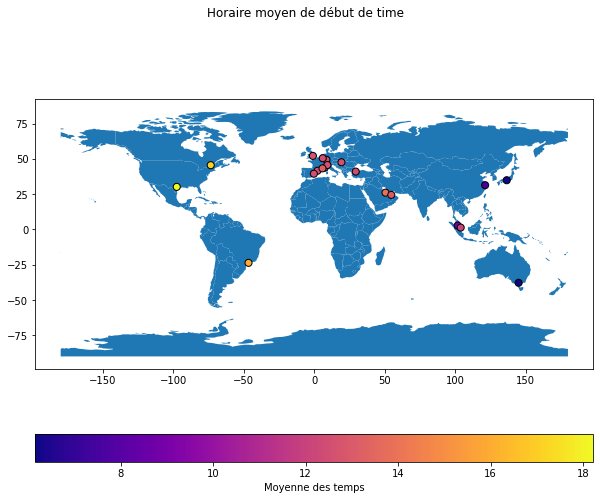

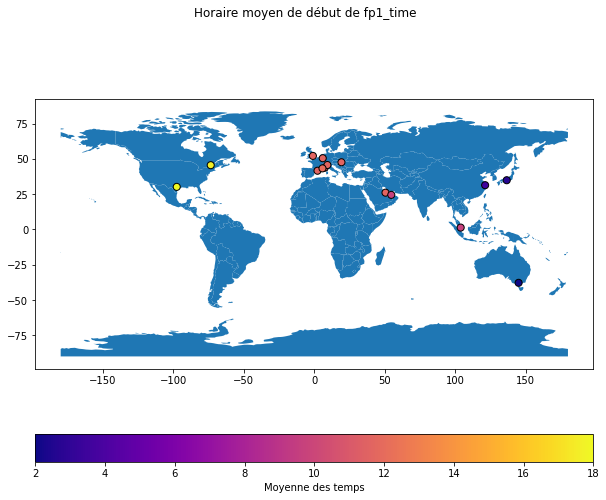

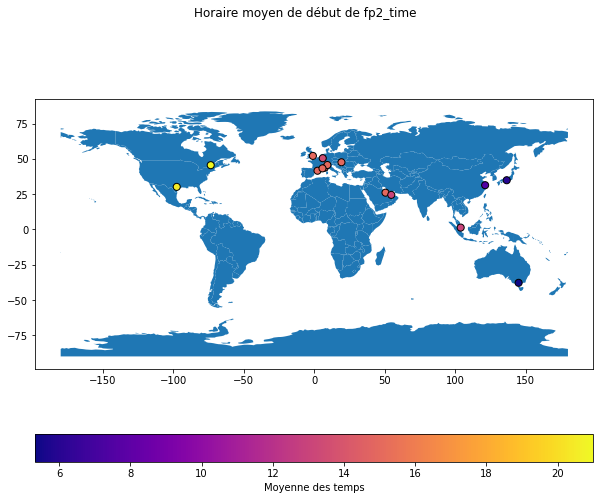

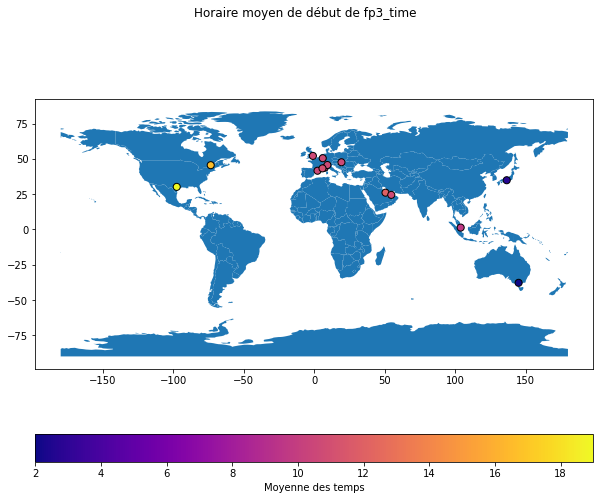

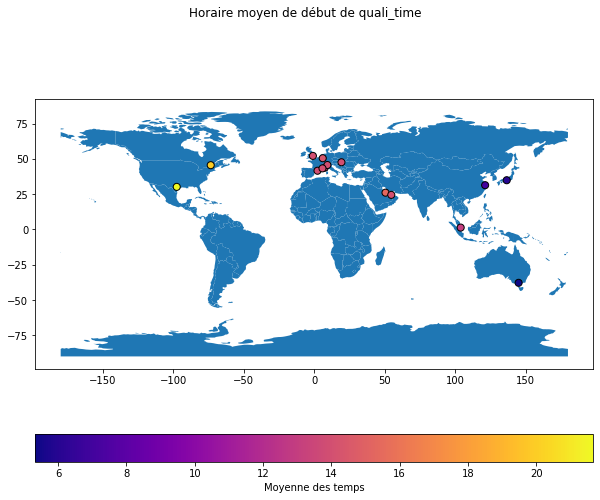

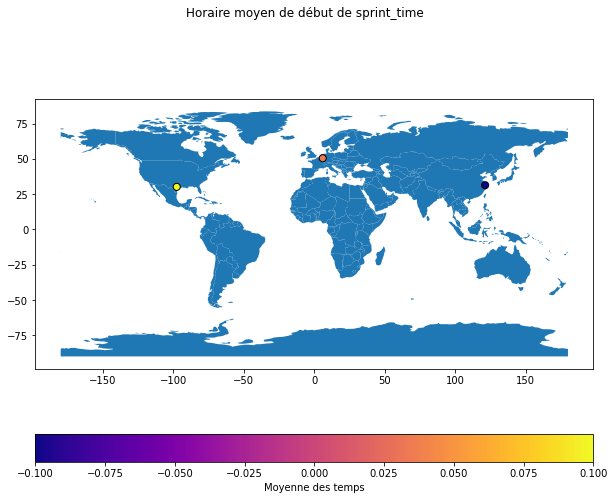

In [61]:
horaire_moyen_run_f1(races)

In [52]:
races

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,1140,2024,20,32,Mexico City Grand Prix,2024-10-27,20:00:00,https://en.wikipedia.org/wiki/2024_Mexico_City...,2024-10-25,18:30:00,2024-10-25,22:00:00,2024-10-26,17:30:00,2024-10-26,21:00:00,\N,\N
1121,1141,2024,21,18,São Paulo Grand Prix,2024-11-03,17:00:00,https://en.wikipedia.org/wiki/2024_S%C3%A3o_Pa...,2024-11-01,14:30:00,2024-11-01,18:30:00,\N,\N,2024-11-02,18:00:00,2024-11-02,14:00:00
1122,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,06:00:00,https://en.wikipedia.org/wiki/2024_Las_Vegas_G...,2024-11-21,02:30:00,2024-11-21,06:00:00,2024-11-22,02:30:00,2024-11-22,06:00:00,\N,\N
1123,1143,2024,23,78,Qatar Grand Prix,2024-12-01,17:00:00,https://en.wikipedia.org/wiki/2024_Qatar_Grand...,2024-11-29,13:30:00,2024-11-29,17:30:00,\N,\N,2024-11-30,17:00:00,2024-11-30,13:00:00


In [13]:
def min_max_pit_stop_drivers(nom_pilote: str, pit_stops: pd.DataFrame, drivers : pd.DataFrame, param: {"min", "max"}):
    pit_stops = pit_stops.copy(deep = True)
    pit_stops["duration"] = pit_stops["milliseconds"]*(10**(-3))
    pit_stop_min = pit_stops.groupby(["raceId","driverId"]).agg({"duration": "min"}).reset_index()
    pit_stop_max = pit_stops.groupby(["raceId","driverId"]).agg({"duration": "max"}).reset_index()
    a = pd.merge(drivers, pit_stop_min, on="driverId", how="left")
    a.rename(columns={"duration": "min_pit_stop"}, inplace=True)
    a = pd.merge(a, pit_stop_max, on=["driverId", "raceId"], how="left")
    a.rename(columns={"duration": "max_pit_stop"}, inplace=True)
    a["min_pit_stop"] = a["min_pit_stop"].astype(float)
    a["max_pit_stop"] = a["max_pit_stop"].astype(float)
    a = a[ ~a["min_pit_stop"].isna()]
    a = a[ ~a["max_pit_stop"].isna()]
    drivers_mean_min_pit_stop = a.groupby("driverRef").agg({"min_pit_stop": "mean"}).reset_index()
    drivers_mean_max_pit_stop = a.groupby("driverRef").agg({"max_pit_stop": "mean"}).reset_index()
    if param == 'min':
        return drivers_mean_min_pit_stop[drivers_mean_max_pit_stop["driverRef"] == nom_pilote]
    else:
        return drivers_mean_max_pit_stop[drivers_mean_max_pit_stop["driverRef"] == nom_pilote]
    

In [16]:
min_max_pit_stop_drivers("hamilton", pit_stops,drivers,"max")

,driverRef,max_pit_stop
22,hamilton,151.802253


In [18]:
def generer_table_fichier(nom_fichier_recherche):
    import os
    dossier = os.path.join(os.path.expanduser("~"), "Desktop", "donnees_formule_un")
    if not os.path.isdir(dossier):
        raise ValueError("Le fichier 'donnees_formule_un' est introuvable sur votre bureau.")
        print("Le dossier n'existe pas :", dossier)
        return
    for nom_fichier in os.listdir(dossier):
        chemin_fichier = os.path.join(dossier, nom_fichier)
        if os.path.isfile(chemin_fichier):
            nom_sans_ext = os.path.splitext(nom_fichier)[0]
            if nom_sans_ext == nom_fichier_recherche:
                with open(chemin_fichier, 'r', encoding='utf-8') as f:
                    for ligne in f:
                        yield ligne.strip()

In [19]:
def nbr_victoire_joueurs():
    count = 0
    joueurs_points = dict()
    begin = 0
    end = 0
    for ligne in generer_table_fichier("driver_standings"):
        if count != 0:
            count_coma = 0
            for i in range(len(ligne)):
                if ligne[i] ==",":
                    count_coma +=1
                    if count_coma == 2:
                        begin = i
                    if count_coma == 3:
                        end = i
                        break
            keys = ligne[begin+1 :end]
            victory = ligne[-1]
            if keys in joueurs_points:
                joueurs_points[keys] = joueurs_points[keys] + int(victory)
            else:
                joueurs_points[keys] = int(victory)
        count += 1
    return joueurs_points

In [20]:
def nbr_points_joueurs():
    count = 0
    joueurs_points = dict()
    begin_name = 0
    end_name = 0
    begin_points = 0
    end_points = 0
    for ligne in generer_table_fichier("driver_standings"):
        if count != 0:
            count_coma = 0
            for i in range(len(ligne)):
                if ligne[i] ==",":
                    count_coma +=1
                    if count_coma == 2:
                        begin_name = i
                    if count_coma == 3:
                        end_name = i
                        begin_points = i
                    if count_coma == 4:
                        end_points = i
                        break
            keys = ligne[begin_name+1 :end_name]
            points = ligne[begin_points+1 :end_points]
            if keys in joueurs_points:
                joueurs_points[keys] = joueurs_points[keys] + float(points)
            else:
                joueurs_points[keys] = float(points)
        count += 1
    return joueurs_points

In [21]:
def nom_joueurs():
    count = 0
    joueurs_nom = dict()
    begin = 0
    end = 0
    for ligne in generer_table_fichier("drivers"):
        if count != 0:
            count_coma = 0
            for i in range(len(ligne)):
                if ligne[i] ==",":
                    count_coma +=1
                    if count_coma == 1:
                        begin = i
                    if count_coma == 2:
                        end = i
                        break
            keys = ligne[:begin]
            name = ligne[begin+2 :end-1]
            joueurs_nom[keys] = name
        count += 1
    return joueurs_nom 

In [22]:
def nbr_victoire_ttal_pilote():
    score = nbr_victoire_joueurs()
    pilotes = nom_joueurs()
    return {pilotes[key]: score[key] for key in score if key in pilotes}

In [23]:
def nbr_points_ttal_pilote():
    score = nbr_points_joueurs()
    pilotes = nom_joueurs()
    return {pilotes[key]: score[key] for key in score if key in pilotes}


In [24]:
def classement_absolu_pilote(pilote: str) -> int:
    drivers = nom_joueurs()
    if pilote not in drivers.values():
        raise ValueError(f"{pilote} n'est pas un pilote référencé")
    score1 = nbr_victoire_ttal_pilote()
    score2 = nbr_points_ttal_pilote()
    res = score1[pilote]
    classement = sorted(score1.items(), key = lambda x: x[1], reverse = True)
    resultat = {}
    for i in range(len(classement)):
        resultat[classement[i][0]] = i+1 
    if res != 0:
        print(f"Le pilote '{pilote}' est arrivé premier "
              f"avec {res} victoires de course "
              "tout au long de sa carrière."
              f"Il aura marqué au total {score2[pilote]}")
    else:
        print(f"Le pilote {pilote} n'a pas de classement "
              "car il n'a aucune victoire de course sur "
              "toute sa carrière."
              f" Il aura marqué au total {score2[pilote]} points.")

    return res

In [25]:
def ttal_vict_pts_pilote(pilote: str)-> list:
    victory = nbr_victoire_ttal_pilote()
    points = nbr_points_ttal_pilote()
    if pilote not in victory.keys():
        raise ValueError(f"{pilote} n'est pas un pilote référencé")
    table = {key : [victory[key],points[key]] for key in victory }
    return table[pilote]

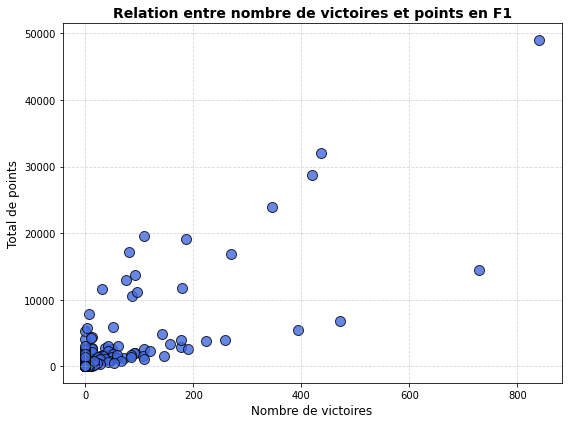

In [28]:
plt.figure(figsize=(8, 6))  # Taille de la figure

plt.scatter(victory_, points_, color='royalblue', edgecolors='k', s=100, alpha=0.8)
plt.title('Relation entre nombre de victoires et points en F1', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de victoires', fontsize=12)
plt.ylabel('Total de points', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Coefficient (slope) : 43.30
Ordonnée à l'origine (intercept) : 122.52
Score R² du modèle : 0.6561


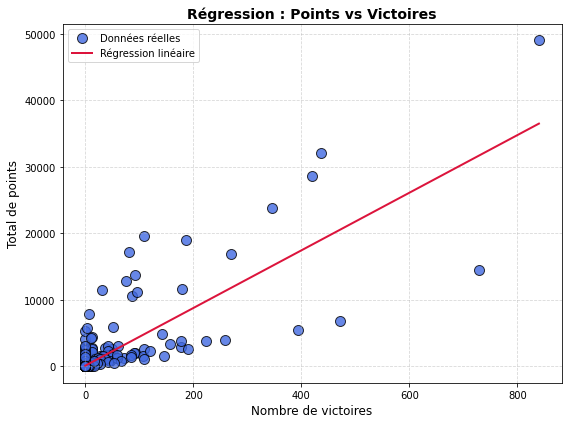

In [29]:
X = np.array(victory_).reshape(-1, 1)
y = np.array(points_)
model = LinearRegression()
model.fit(X, y)
score = model.score(X, y)
print(f"Coefficient (slope) : {model.coef_[0]:.2f}")
print(f"Ordonnée à l'origine (intercept) : {model.intercept_:.2f}")
print(f"Score R² du modèle : {score:.4f}")
x_range = np.linspace(min(victory_), max(victory_), 100).reshape(-1, 1)
y_pred = model.predict(x_range)
plt.figure(figsize=(8, 6))
plt.scatter(victory_, points_, color='royalblue', edgecolors='k', s=100, alpha=0.8, label='Données réelles')
plt.plot(x_range, y_pred, color='crimson', linewidth=2, label='Régression linéaire')
plt.title('Régression : Points vs Victoires', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de victoires', fontsize=12)
plt.ylabel('Total de points', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


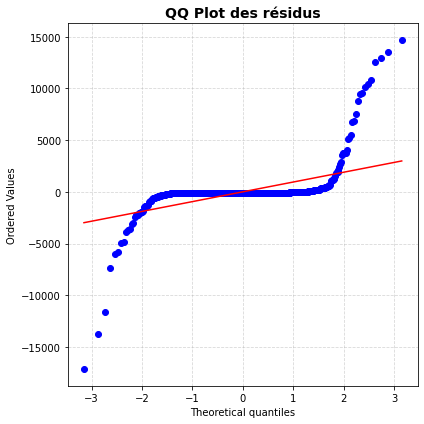

In [30]:
y_pred = model.predict(X)
residuals = y - y_pred
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot des résidus", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

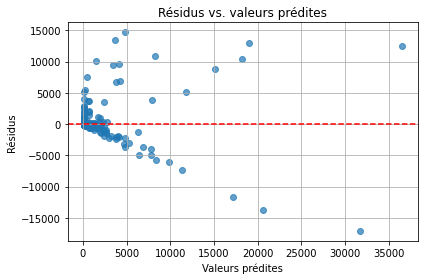

In [31]:
residuals = y - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs. valeurs prédites")
plt.grid(True)
plt.tight_layout()
plt.show()

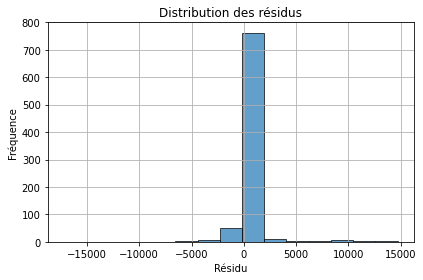

In [32]:
plt.hist(residuals, bins=15, edgecolor='black', alpha=0.7)
plt.title("Distribution des résidus")
plt.xlabel("Résidu")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.show()